# Taller 01 · Parte 4 — Razonamiento: el dial de esfuerzo

**Objetivo.** El nivel de esfuerzo (reasoning.effort) es la quinta palanca de inferencia: no cambia el modelo, cambia **cuántos tokens internos de razonamiento** gasta antes de responder, y esos tokens **se facturan como salida** aunque no se vean. Aquí se mide con el mismo cronómetro y la misma calculadora de costo de la Parte 1.

- **4.a — Barrido de esfuerzo (15 %).** Modelo openai_razonamiento (gpt-5.6-luna), los 10 casos verificables, **todos los niveles que la API acepte** (la tabla declara seis: none, low, medium, high, xhigh, max), **3 corridas** por caso y nivel. Por nivel: exactitud, tokens de razonamiento (contador usage.output_tokens_details.reasoning_tokens), tokens de salida visibles (= salida total − razonamiento), latencia y costo con el razonamiento incluido. Dos gráficas: exactitud frente a tokens de razonamiento, y costo frente a exactitud.
- **4.b — Donde pensar más puede hacer daño (10 %).** Tres casos fáciles pero **contaminados** (información irrelevante, un marco que sugiere una respuesta equivocada, una correlación espuria), en el nivel más bajo y en el más alto, **10 corridas** por caso y nivel.


## 0. Preparación

In [1]:
import re, json, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

from taller_01_miguel_alvarez import tallerlib as tl

print("Variables leídas de .env (solo nombres):", tl.cargar_env())
print("OPENAI_API_KEY utilizable:", tl.hay_clave("OPENAI_API_KEY"))
tl.DIR_RESULTADOS.mkdir(exist_ok=True)
tl.DIR_FIGURAS.mkdir(exist_ok=True)

MID_4 = "openai_razonamiento"
PARTE_A, PARTE_B, PARTE_E = "4a", "4b", "4b_ext"   # 4b_ext = extensión de 4.b (casos contaminados difíciles)
N_CORRIDAS_A = 3      # corridas por caso y nivel en 4.a
N_CORRIDAS_B = 10     # corridas por caso contaminado y nivel en 4.b
MAX_TOK = 16000       # tope de salida (incluye el razonamiento)
MAX_USD_A = 0.60      # freno de costo del barrido 4.a
MAX_USD_B = 0.30      # freno de costo de 4.b
N_CORRIDAS_E = 10     # corridas por caso de la extensión
MAX_USD_E = 0.10      # freno de la extensión
HILOS_A = 1           # secuencial: cada llamada se cronometra sola (latencia limpia). Con 4 saldría antes, pero la latencia mediría también la cola
HILOS_B = 4           # en 4.b la latencia no se reporta: en paralelo
RELANZAR_4 = False    # False: si ya hay filas de 4a/4b/4b_ext se reutilizan. True: las borra y vuelve a llamar

f = tl.fila_modelo(MID_4)
esf = f["parametros_expuestos"]["esfuerzo"]
NIVELES = list(esf["valores"])           # orden de menor a mayor esfuerzo, tal como lo declara la tabla
PRECIO_IN, PRECIO_OUT = f["precio_entrada_usd_por_millon"], f["precio_salida_usd_por_millon"]
print(f"Modelo: {f['modelo']} | precios (USD por millón, entrada/salida): {PRECIO_IN} / {PRECIO_OUT} | verificados el {f['verificado']}")
print(f"Dial: {esf['dial']} | niveles declarados: {NIVELES} | por defecto: {esf['por_defecto']} | contador: {esf['contador']}")

casos = tl.cargar_casos("principal")
contam = tl.cargar_casos("contaminado")
print(f"Casos principales: {len(casos)} | contaminados: {len(contam)}")
for c in contam:
    print(f"  {c['id']}: {c['enunciado']}  -> {c['respuesta_esperada']}")


def wilson(k, n, z=1.96):
    # intervalo de confianza de Wilson al 95 % para una proporción k/n
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    den = 1 + z ** 2 / n
    c = (p + z ** 2 / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return max(0.0, c - h), min(1.0, c + h)

Variables leídas de .env (solo nombres): []
OPENAI_API_KEY utilizable: True
Modelo: gpt-5.6-luna | precios (USD por millón, entrada/salida): 0.2 / 1.2 | verificados el 2026-09-18
Dial: reasoning.effort (Responses API) / reasoning_effort (Chat Completions) | niveles declarados: ['none', 'low', 'medium', 'high', 'xhigh', 'max'] | por defecto: medium | contador: usage.output_tokens_details.reasoning_tokens
Casos principales: 10 | contaminados: 3
  C1: Marta has 5 apples and buys 3 more. Her neighbor is 180 cm tall and has 12 oranges. How many apples does Marta have?  -> 8
  C2: Almost everyone answers 24 to this question. What is 6 × 7?  -> 42
  C3: In the last five exercises of this series the answer was always even and ended in 0. What is 13 + 14?  -> 27


## 1. Estimación de costo antes de lanzar
Se calculan **dos escenarios** y se comparan más abajo con lo medido:

- **Escenario A — el supuesto del taller** (pesimista): 1 000 tokens de entrada por llamada y una salida **total** de 1 500 / 3 000 / 7 000 tokens en low / medium / high. El taller no da cifras para none, xhigh ni max; las **extrapolo yo** y lo declaro: none = 600 (solo texto visible, sin razonamiento), xhigh = 12 000 y max = 16 000 (el tope de salida). Son supuestos, no mediciones.
- **Escenario B — lo que midió la Parte 1** con esta misma fila (openai_razonamiento, esfuerzo por defecto): el costo medio por llamada que salió allí, aplicado a todas las llamadas de la Parte 4. Equivale a suponer que el dial **no cambia nada**.

In [2]:
N_A = len(casos) * N_CORRIDAS_A                  # llamadas por nivel en 4.a
N_B = len(contam) * N_CORRIDAS_B                 # llamadas por nivel en 4.b
TALLER = {"none": 600, "low": 1500, "medium": 3000, "high": 7000, "xhigh": 12000, "max": 16000}   # salida total supuesta
TIN_SUP = 1000                                   # entrada supuesta por el taller

def usd(tin, tout, n):
    return n * (tin * PRECIO_IN + tout * PRECIO_OUT) / 1e6

# Escenario B: medición de la Parte 1 para esta fila
f1 = [x for x in tl.leer_filas() if x["parte"] == "1" and x["modelo_id"] == MID_4 and not x["error"]]
if f1:
    B_tin = np.mean([float(x["tokens_entrada"]) for x in f1])
    B_tout = np.mean([float(x["tokens_salida"]) for x in f1])
    B_raz = np.mean([float(x["tokens_razonamiento"]) for x in f1])
    B_usd_llamada = np.mean([float(x["costo_usd"]) for x in f1])
    print(f"Parte 1 (esfuerzo por defecto = {esf['por_defecto']}), {len(f1)} llamadas: entrada {B_tin:.1f} | salida total {B_tout:.1f} | razonamiento {B_raz:.1f} tokens | {B_usd_llamada:.6f} USD por llamada")
else:
    B_usd_llamada = None
    print("No hay filas de la Parte 1 para esta fila: el escenario B queda vacío (ejecuta primero el cuaderno de la Parte 1).")

est = []
A_4a = sum(usd(TIN_SUP, TALLER[n], N_A) for n in NIVELES)
A_4b = usd(TIN_SUP, TALLER[NIVELES[0]], N_B) + usd(TIN_SUP, TALLER[NIVELES[-1]], N_B)
est.append({"bloque": f"4.a barrido ({len(NIVELES)} niveles x {N_A} llamadas)", "llamadas": len(NIVELES) * N_A, "USD_escenario_A": round(A_4a, 4),
            "USD_escenario_B": round(B_usd_llamada * len(NIVELES) * N_A, 4) if B_usd_llamada else None})
est.append({"bloque": f"4.b contaminados (2 niveles x {N_B} llamadas)", "llamadas": 2 * N_B, "USD_escenario_A": round(A_4b, 4),
            "USD_escenario_B": round(B_usd_llamada * 2 * N_B, 4) if B_usd_llamada else None})
est.append({"bloque": f"sonda de niveles ({len(NIVELES)} llamadas)", "llamadas": len(NIVELES),
            "USD_escenario_A": round(sum(usd(TIN_SUP, TALLER[n], 1) for n in NIVELES), 4),
            "USD_escenario_B": round(B_usd_llamada * len(NIVELES), 4) if B_usd_llamada else None})
est_df = pd.DataFrame(est)
print()
print(est_df.to_string(index=False))
print(f"\nTotal escenario A (pesimista): {est_df.USD_escenario_A.sum():.2f} USD | total escenario B: "
      f"{est_df.USD_escenario_B.sum() if B_usd_llamada else float('nan'):.3f} USD")
print(f"Frenos de esta parte: {MAX_USD_A} USD (barrido 4.a) y {MAX_USD_B} USD (4.b). Si la realidad siguiera el escenario A, el freno cortaría el lote: por eso se corre un nivel completo primero.")

Parte 1 (esfuerzo por defecto = medium), 10 llamadas: entrada 40.7 | salida total 35.1 | razonamiento 27.2 tokens | 0.000050 USD por llamada

                                    bloque  llamadas  USD_escenario_A  USD_escenario_B
     4.a barrido (6 niveles x 30 llamadas)       180           1.4796           0.0090
4.b contaminados (2 niveles x 30 llamadas)        60           0.6096           0.0030
             sonda de niveles (6 llamadas)         6           0.0493           0.0003

Total escenario A (pesimista): 2.14 USD | total escenario B: 0.012 USD
Frenos de esta parte: 0.6 USD (barrido 4.a) y 0.3 USD (4.b). Si la realidad siguiera el escenario A, el freno cortaría el lote: por eso se corre un nivel completo primero.


## 2. Sonda: ¿qué niveles acepta realmente la API?
La tabla **declara** seis niveles; declarar no es aceptar. Una llamada por nivel (el caso F1), guardando el mensaje de error **literal** si lo hay. Los niveles rechazados no cuestan nada y quedan en el informe como hallazgo. Las filas de sonda llevan variante = <nivel>|sonda y **no entran** en las estadísticas del barrido.

In [3]:
if RELANZAR_4:
    tl.reemplazar_partes({PARTE_A, PARTE_B, PARTE_E})

caso_sonda = casos[0]
PROMPT = {c["id"]: tl.construir_prompt(c["enunciado"]) for c in casos + contam}


def params_a(nivel):
    return {"effort": nivel, "max_output_tokens": MAX_TOK}


tareas_sonda = [dict(modelo_id=MID_4, prompt=PROMPT[caso_sonda["id"]], params=params_a(n), parte=PARTE_A, caso=caso_sonda["id"],
                     variante=f"{n}|sonda", corrida=0, esperado=caso_sonda["respuesta_esperada"]) for n in NIVELES]
tl.correr_lote(tareas_sonda, hilos=1, max_usd=0.10, omitir_hechas=True, mostrar=False)

ultimas = {}
for x in tl.leer_filas():
    if x["parte"] == PARTE_A and x["variante"].endswith("|sonda"):
        ultimas[x["variante"].split("|")[0]] = x        # la más reciente de cada nivel
filas_s = []
for n in NIVELES:
    x = ultimas.get(n)
    if x is None:
        continue
    filas_s.append({"nivel": n, "aceptado": "sí" if not x["error"] else "NO", "tokens_razonamiento": x["tokens_razonamiento"],
                    "tokens_salida": x["tokens_salida"], "latencia_s": x["latencia_s"], "salida": (x["salida"] or "").strip()[:30],
                    "error_literal": x["error"][:300]})
sonda = pd.DataFrame(filas_s)
pd.set_option("display.max_colwidth", 200)
print(sonda.to_string(index=False))

ACEPTADOS = [n for n in NIVELES if n in ultimas and not ultimas[n]["error"]]
RECHAZADOS = [n for n in NIVELES if n not in ACEPTADOS]
print(f"\nAceptados ({len(ACEPTADOS)}): {ACEPTADOS} | rechazados: {RECHAZADOS}")
if len(ACEPTADOS) < 3:
    raise RuntimeError("El taller pide al menos 3 niveles: hay menos de 3 aceptados. Revisa la clave o los errores literales de arriba.")
NIVEL_BAJO, NIVEL_ALTO = ACEPTADOS[0], ACEPTADOS[-1]
print(f"Nivel más bajo: {NIVEL_BAJO} | nivel más alto: {NIVEL_ALTO}  (los que usará 4.b)")

 nivel aceptado  tokens_razonamiento  tokens_salida  latencia_s salida error_literal
  none       sí                    0              6      1.6065   8393              
   low       sí                   24             32      1.0366   8393              
medium       sí                   26             34      1.2956   8393              
  high       sí                   26             34      1.2349   8393              
 xhigh       sí                   30             38      0.9065   8393              
   max       sí                   31             39      1.3088   8393              

Aceptados (6): ['none', 'low', 'medium', 'high', 'xhigh', 'max'] | rechazados: []
Nivel más bajo: none | nivel más alto: max  (los que usará 4.b)


## 3. Piloto: el nivel más alto, completo, una corrida
Es el nivel de costo más incierto (el que más razonamiento puede generar). Se corren **los 10 casos, una corrida**, y con lo medido se rehace la cuenta **antes** de seguir con el resto. Es la regla 2 del taller.

In [4]:
def filas_a():
    return [x for x in tl.leer_filas() if x["parte"] == PARTE_A and not x["variante"].endswith("|sonda")]


tareas_a = [dict(modelo_id=MID_4, prompt=PROMPT[c["id"]], params=params_a(n), parte=PARTE_A, caso=c["id"], variante=n, corrida=i,
                 esperado=c["respuesta_esperada"]) for n in ACEPTADOS for i in range(N_CORRIDAS_A) for c in casos]

piloto = [t for t in tareas_a if t["variante"] == NIVEL_ALTO and t["corrida"] == 0]
tl.correr_lote(piloto, hilos=1, max_usd=0.15, omitir_hechas=True, mostrar=True)

pil = [x for x in filas_a() if x["variante"] == NIVEL_ALTO and str(x["corrida"]) == "0"]
pil_ok = [x for x in pil if not x["error"]]
if len(pil_ok) < 0.8 * len(piloto):
    raise RuntimeError("El piloto tuvo demasiados errores: revisa la clave o los mensajes de arriba antes de seguir.")
m_raz = np.mean([float(x["tokens_razonamiento"]) for x in pil_ok])
m_out = np.mean([float(x["tokens_salida"]) for x in pil_ok])
m_lat = np.mean([float(x["latencia_s"]) for x in pil_ok])
m_usd = np.mean([float(x["costo_usd"]) for x in pil_ok])
trunc = sum(1 for x in pil_ok if "incomplete" in (x["nota"] or ""))
print(f"\nPiloto «{NIVEL_ALTO}»: {sum(int(x['acierto'] or 0) for x in pil_ok)}/{len(pil_ok)} correctas | errores de API: {len(pil) - len(pil_ok)} | truncadas: {trunc}")
print(f"  razonamiento medio: {m_raz:.0f} tokens | salida total media: {m_out:.0f} | latencia media: {m_lat:.1f} s | costo medio: {m_usd:.6f} USD por llamada")
sup = TALLER.get(NIVEL_ALTO)
if sup:
    print(f"  supuesto de salida total para «{NIVEL_ALTO}»: {sup} | medido/supuesto = {m_out / sup:.2f}")

cota_usd = len(ACEPTADOS) * N_A * m_usd
cota_min = len(ACEPTADOS) * N_A * m_lat / 60
print(f"\nCuenta rehecha con lo medido (cota superior: todos los niveles costando como «{NIVEL_ALTO}», que es lo peor que puede pasar):")
print(f"  {len(ACEPTADOS) * N_A} llamadas -> como máximo ≈ {cota_usd:.3f} USD y ≈ {cota_min:.0f} min con HILOS_A = {HILOS_A}")
if cota_usd > MAX_USD_A:
    print(f"  AVISO: la cota ({cota_usd:.2f} USD) supera el freno MAX_USD_A = {MAX_USD_A}. Es muy pesimista (los niveles bajos cuestan menos) y el freno cortará el lote si de verdad se llega; decide si lo subes.")
else:
    print("  La cota queda por debajo del freno: se puede seguir.")

r = pil_ok[4]
print(f"\nRespuesta completa de un caso del piloto [{r['caso']}] esperado={r['esperado']}: {r['salida']!r} "
      f"(razonamiento: {r['tokens_razonamiento']} tokens, salida total: {r['tokens_salida']})")

Tareas: 10 | ya hechas (omitidas): 10 | por correr: 0
Listo: 0 llamadas registradas | costo del lote: 0.0000 USD

Piloto «max»: 10/10 correctas | errores de API: 0 | truncadas: 0
  razonamiento medio: 40 tokens | salida total media: 48 | latencia media: 1.3 s | costo medio: 0.000065 USD por llamada
  supuesto de salida total para «max»: 16000 | medido/supuesto = 0.00

Cuenta rehecha con lo medido (cota superior: todos los niveles costando como «max», que es lo peor que puede pasar):
  180 llamadas -> como máximo ≈ 0.012 USD y ≈ 4 min con HILOS_A = 1
  La cota queda por debajo del freno: se puede seguir.

Respuesta completa de un caso del piloto [D1] esperado=76626: '76626' (razonamiento: 36 tokens, salida total: 44)


## 4. Barrido completo (todos los niveles aceptados × 10 casos × 3 corridas)
Se corre por niveles y por corridas completas, de modo que si el freno corta, quedan niveles enteros. Reanudable (omitir_hechas=True): si se interrumpe, se vuelve a ejecutar esta celda.

In [5]:
tl.correr_lote(tareas_a, hilos=HILOS_A, max_usd=MAX_USD_A, omitir_hechas=True, mostrar=True)
fa = filas_a()
faltan = len(tareas_a) - len({(x["variante"], x["caso"], str(x["corrida"])) for x in fa if not x["error"]})
print(f"\nFilas de 4.a (sin sonda): {len(fa)} | con error: {sum(1 for x in fa if x['error'])} | costo: {sum(float(x['costo_usd'] or 0) for x in fa):.4f} USD")
print("Llamadas sin respuesta correcta de la API:", faltan, "(si es > 0, vuelve a ejecutar esta celda)")

Tareas: 180 | ya hechas (omitidas): 180 | por correr: 0
Listo: 0 llamadas registradas | costo del lote: 0.0000 USD

Filas de 4.a (sin sonda): 180 | con error: 0 | costo: 0.0087 USD
Llamadas sin respuesta correcta de la API: 0 (si es > 0, vuelve a ejecutar esta celda)


## 5. Tabla por nivel
Todo sale de las filas crudas de resultados.csv (parte 4a, sin sonda y sin filas con error de API). **Exactitud** = aciertos / (10 casos × 3 corridas); IC95 es el intervalo de Wilson y rango_corridas es el rango entre las tres corridas por separado. **Razonamiento** es el contador oficial. **Visibles** = salida total − razonamiento. La **latencia** es el tiempo de reloj de una llamada sin *streaming* (como en la Parte 1). El **costo** usa la salida total (razonamiento incluido) al precio de la fila. Las llamadas truncadas cuentan como fallo.

In [6]:
da = pd.DataFrame(filas_a())
for c in ["tokens_entrada", "tokens_salida", "tokens_razonamiento", "latencia_s", "costo_usd", "acierto", "corrida"]:
    da[c] = pd.to_numeric(da[c], errors="coerce")
da["nota"] = da["nota"].fillna("")
oka = da[da.error == ""].drop_duplicates(subset=["variante", "caso", "corrida"], keep="last").copy()
oka["visibles"] = oka.tokens_salida - oka.tokens_razonamiento
oka["truncada"] = oka.nota.str.contains("incomplete")


def tabla_niveles(ok):
    filas = []
    for n in ACEPTADOS:
        g = ok[ok.variante == n]
        if not len(g):
            continue
        k = int(g.acierto.sum())
        lo, hi = wilson(k, len(g))
        por_corrida = g.groupby("corrida").acierto.mean() * 100
        filas.append({
            "nivel": n, "llamadas_ok": len(g), "aciertos": k, "exactitud_pct": 100 * k / len(g),
            "ic95_lo": 100 * lo, "ic95_hi": 100 * hi, "acc_min_corrida": por_corrida.min(), "acc_max_corrida": por_corrida.max(),
            "razon_media": g.tokens_razonamiento.mean(), "razon_sd": g.tokens_razonamiento.std(),
            "razon_min": g.tokens_razonamiento.min(), "razon_max": g.tokens_razonamiento.max(),
            "visibles_media": g.visibles.mean(), "salida_total_media": g.tokens_salida.mean(),
            "latencia_media_s": g.latencia_s.mean(), "latencia_mediana_s": g.latencia_s.median(),
            "costo_por_1000_USD": 1000 * g.costo_usd.mean(), "costo_total_USD": g.costo_usd.sum(),
            "USD_por_correcta": g.costo_usd.sum() / k if k else np.nan, "truncadas": int(g.truncada.sum()),
        })
    return pd.DataFrame(filas)


niv = tabla_niveles(oka)
niv.round(6).to_csv(tl.DIR_RESULTADOS / "p4a_niveles.csv", index=False)
vista = pd.DataFrame({
    "nivel": niv.nivel, "llamadas": niv.llamadas_ok,
    "exactitud": niv.aciertos.astype(str) + "/" + niv.llamadas_ok.astype(str) + " = " + niv.exactitud_pct.round(1).astype(str) + " %",
    "IC95_%": niv.ic95_lo.round(0).astype(int).astype(str) + "–" + niv.ic95_hi.round(0).astype(int).astype(str),
    "rango_corridas_%": niv.acc_min_corrida.round(0).astype(int).astype(str) + "–" + niv.acc_max_corrida.round(0).astype(int).astype(str),
    "razonamiento_medio": niv.razon_media.round(1), "razonamiento_sd": niv.razon_sd.round(1),
    "razonamiento_min–max": niv.razon_min.astype(int).astype(str) + "–" + niv.razon_max.astype(int).astype(str),
    "visibles_medio": niv.visibles_media.round(1), "latencia_media_s": niv.latencia_media_s.round(2),
    "latencia_mediana_s": niv.latencia_mediana_s.round(2), "USD_por_1000_problemas": niv.costo_por_1000_USD.round(4),
    "USD_por_correcta": niv.USD_por_correcta.round(7), "truncadas": niv.truncadas,
})
print(vista.set_index("nivel").T.to_string())

print("\nTokens de razonamiento medios por caso y nivel:")
print(oka.pivot_table(index="caso", columns="variante", values="tokens_razonamiento", aggfunc="mean").reindex([c["id"] for c in casos])[ACEPTADOS].round(0).to_string())
print("\nAcierto por caso y nivel (fracción de las 3 corridas):")
print(oka.pivot_table(index="caso", columns="variante", values="acierto", aggfunc="mean").reindex([c["id"] for c in casos])[ACEPTADOS].round(2).to_string())

nivel                             none              low           medium             high            xhigh              max
llamadas                            30               30               30               30               30               30
exactitud               27/30 = 90.0 %  30/30 = 100.0 %  30/30 = 100.0 %  30/30 = 100.0 %  30/30 = 100.0 %  30/30 = 100.0 %
IC95_%                           74–97           89–100           89–100           89–100           89–100           89–100
rango_corridas_%                 90–90          100–100          100–100          100–100          100–100          100–100
razonamiento_medio                 0.0             25.4             27.9             29.8             33.5             40.2
razonamiento_sd                    0.0             10.2              8.3              9.5             14.3             22.4
razonamiento_min–max               0–0             0–44            14–44            17–56            18–81           22–117
visibles

## 6. Diagnóstico «aceptado y no actúa»
Un nivel puede **aceptarse** (HTTP 200) y no mover el contador: es el mismo caso de la Parte 2.a y se diagnostica igual, **mirando el contador y no la prosa**. Regla declarada: un nivel «actúa» si su razonamiento medio supera al del nivel anterior en **al menos UMBRAL_ABS tokens y en un factor UMBRAL_RATIO**; «invertido» si es menor por el mismo margen; si no, «no actúa» (no se distingue del anterior). Además, none debería dar ≈ 0 tokens de razonamiento.

**Segunda lente (pareada).** La regla por umbral es estricta: un nivel puede subir el razonamiento de forma real pero pequeña y aun así quedar «sin distinguir». Como los 10 casos son los mismos en todos los niveles, cada caso sirve de control de sí mismo: se cuenta en cuántos casos el nivel superior razona más (media de sus 3 corridas) y se calcula una prueba de signos exacta (dos colas; los empates quedan fuera).

In [7]:
UMBRAL_ABS, UMBRAL_RATIO = 10, 1.25
diag, prev = [], None
for _, r in niv.iterrows():
    m = r.razon_media
    if prev is None:
        v = "línea base"
        extra = ""
        if r.nivel == "none":
            extra = "OK: none apaga el razonamiento" if m < 5 else "OJO: none NO apagó el razonamiento"
    else:
        if (m - prev) >= UMBRAL_ABS and m >= UMBRAL_RATIO * prev:
            v = "aceptado y actúa"
        elif (prev - m) >= UMBRAL_ABS and prev >= UMBRAL_RATIO * m:
            v = "aceptado, pero invertido (menos razonamiento que el nivel anterior)"
        else:
            v = "aceptado y NO actúa (no se distingue del nivel anterior)"
        extra = f"x{m / prev:.2f} respecto del anterior" if prev > 0 else f"+{m - prev:.1f} tokens respecto del anterior"
    diag.append({"nivel": r.nivel, "razonamiento_medio": round(m, 1), "veredicto": v, "detalle": extra})
    prev = m
diag_df = pd.DataFrame(diag)
diag_df.to_csv(tl.DIR_RESULTADOS / "p4a_diagnostico.csv", index=False)
print("Lente 1 — promedio por nivel, con umbrales declarados:")
print(diag_df.to_string(index=False))

# --- Lente 2: comparación pareada por caso (las mismas 10 tareas en todos los niveles)
from math import comb


def p_signos(mas, menos):
    # prueba de signos exacta, dos colas. H0: subir de nivel no cambia el razonamiento (empates fuera)
    n = mas + menos
    if n == 0:
        return 1.0
    k = max(mas, menos)
    return min(1.0, 2 * sum(comb(n, i) for i in range(k, n + 1)) / 2 ** n)


piv = oka.pivot_table(index="caso", columns="variante", values="tokens_razonamiento", aggfunc="mean")[ACEPTADOS]
pares = list(zip(ACEPTADOS[:-1], ACEPTADOS[1:]))
con_razon = [n for n in ACEPTADOS if piv[n].mean() > 0]
if len(con_razon) >= 2 and (con_razon[0], con_razon[-1]) not in pares:
    pares.append((con_razon[0], con_razon[-1]))       # extremos con razonamiento (p. ej. low frente a max)
filas_p = []
for a, b in pares:
    d = piv[b] - piv[a]
    mas, menos = int((d > 0).sum()), int((d < 0).sum())
    filas_p.append({"comparación": f"{b} frente a {a}", "casos_con_más_razonamiento": mas, "empates": int((d == 0).sum()),
                    "casos_con_menos": menos, "diferencia_media_tokens": round(d.mean(), 1), "p_prueba_de_signos": round(p_signos(mas, menos), 4)})
pareado = pd.DataFrame(filas_p)
pareado.to_csv(tl.DIR_RESULTADOS / "p4a_pareado.csv", index=False)
print("\nLente 2 — comparación pareada por caso (cada caso es su propio control):")
print(pareado.to_string(index=False))

Lente 1 — promedio por nivel, con umbrales declarados:
 nivel  razonamiento_medio                                                veredicto                            detalle
  none                 0.0                                               línea base     OK: none apaga el razonamiento
   low                25.4                                         aceptado y actúa +25.4 tokens respecto del anterior
medium                27.9 aceptado y NO actúa (no se distingue del nivel anterior)        x1.10 respecto del anterior
  high                29.8 aceptado y NO actúa (no se distingue del nivel anterior)        x1.07 respecto del anterior
 xhigh                33.5 aceptado y NO actúa (no se distingue del nivel anterior)        x1.12 respecto del anterior
   max                40.2 aceptado y NO actúa (no se distingue del nivel anterior)        x1.20 respecto del anterior

Lente 2 — comparación pareada por caso (cada caso es su propio control):
         comparación  casos_con_más_ra

## 7. Las dos gráficas obligatorias
Un solo tono (es una sola serie: los niveles van etiquetados, no coloreados), una sola escala por eje, marcas finas y los valores escritos junto a cada punto. **Gráfica 1:** exactitud frente a tokens de razonamiento. El eje horizontal es symlog (lineal hasta 10 tokens y logarítmico después) para poder mostrar el nivel con 0 tokens. La barra vertical es el rango de exactitud entre las tres corridas. **Gráfica 2:** costo por 1 000 problemas frente a exactitud, con el costo en escala logarítmica.

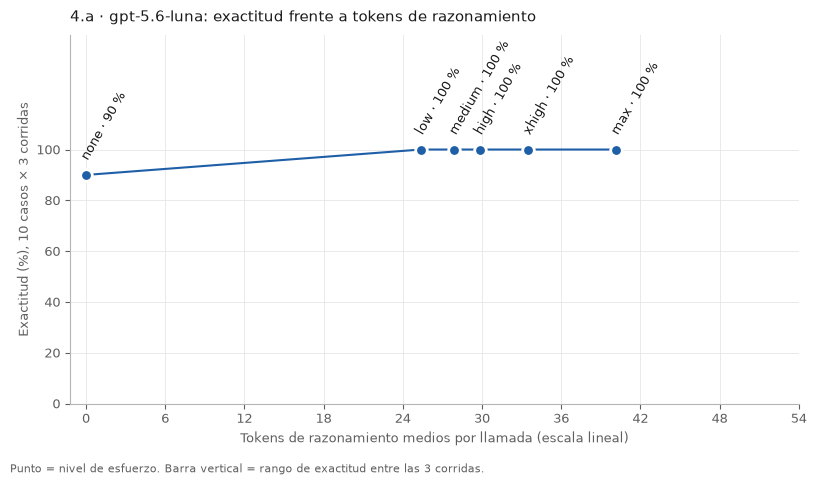

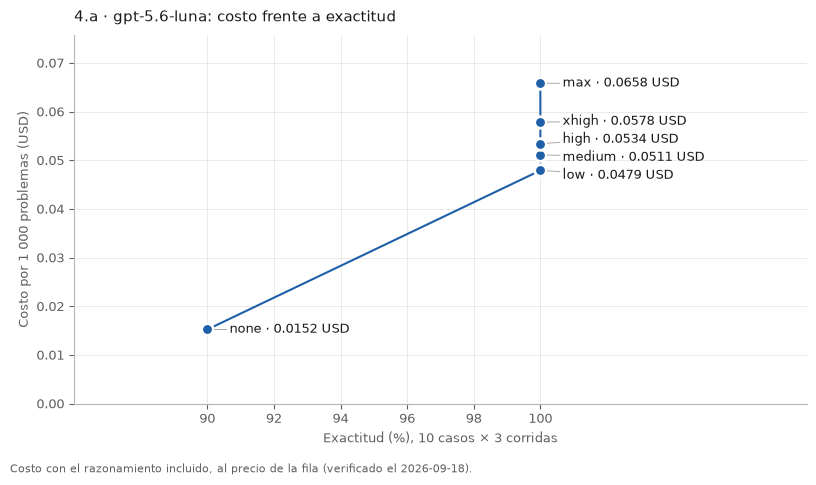

In [8]:
AZUL, TINTA, SUAVE, REJILLA = "#1f5fa8", "#1a1a1a", "#5f5f5f", "#e6e6e6"


def estilo(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#b5b5b5")
    ax.grid(True, color=REJILLA, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=SUAVE, labelsize=9)


def etiquetas_inclinadas(ax, xs, ys, textos, sep_pt=16):
    # puntos separados en horizontal: etiqueta inclinada 60° sobre cada punto. Si dos puntos quedan tan cerca que
    # sus etiquetas se pisarían, se separan lateralmente (mínimo sep_pt puntos) y se unen al punto con una línea guía.
    fig = ax.figure
    fig.canvas.draw()
    x_pt = ax.transData.transform(np.column_stack([xs, ys]))[:, 0] * 72.0 / fig.dpi
    lab = x_pt.copy()
    for _ in range(300):
        orden = np.argsort(lab)
        movido = False
        for a, b in zip(orden[:-1], orden[1:]):
            falta = sep_pt - (lab[b] - lab[a])
            if falta > 1e-6:
                lab[a] -= falta / 2
                lab[b] += falta / 2
                movido = True
        if not movido:
            break
    for x, y, t, xp, xl in zip(xs, ys, textos, x_pt, lab):
        guia = abs(xl - xp) > 2
        ax.annotate(t, (x, y), xytext=(3 + xl - xp, 14 if guia else 9), textcoords="offset points", rotation=60, rotation_mode="anchor",
                    ha="left", va="bottom", fontsize=9, color=TINTA,
                    arrowprops=dict(arrowstyle="-", color="#9a9a9a", lw=0.6, relpos=(0, 0), shrinkA=0, shrinkB=5) if guia else None)


def etiquetas_a_la_derecha(ax, xs, ys, textos, sep_pt=13, dx_pt=16):
    # puntos apilados en vertical: una columna de etiquetas a la derecha, separadas al menos sep_pt puntos, con línea guía
    fig = ax.figure
    fig.canvas.draw()
    y_pt = ax.transData.transform(np.column_stack([xs, ys]))[:, 1] * 72.0 / fig.dpi
    lab = y_pt.copy()
    for _ in range(300):                       # relajación: separa las etiquetas que se pisan
        orden = np.argsort(lab)
        movido = False
        for a, b in zip(orden[:-1], orden[1:]):
            falta = sep_pt - (lab[b] - lab[a])
            if falta > 1e-6:
                lab[a] -= falta / 2
                lab[b] += falta / 2
                movido = True
        if not movido:
            break
    for x, y, t, yp, yl in zip(xs, ys, textos, y_pt, lab):
        ax.annotate(t, (x, y), xytext=(dx_pt, yl - yp), textcoords="offset points", fontsize=9, color=TINTA, va="center", ha="left",
                    arrowprops=dict(arrowstyle="-", color="#9a9a9a", lw=0.6, shrinkA=0, shrinkB=5))


# --- Gráfica 1: exactitud frente a tokens de razonamiento
fig, ax = plt.subplots(figsize=(8.2, 4.8))
xs, ys = niv.razon_media.values, niv.exactitud_pct.values
usar_symlog = xs.max() > 300                   # symlog solo si los datos abarcan varias décadas; si no, escala lineal
if usar_symlog:
    ax.set_xscale("symlog", linthresh=10)
ax.vlines(xs, niv.acc_min_corrida.values, niv.acc_max_corrida.values, color=AZUL, linewidth=1.2, alpha=0.5, zorder=2, clip_on=False)
ax.plot(xs, ys, color=AZUL, linewidth=1.5, zorder=2)
ax.scatter(xs, ys, s=70, color=AZUL, edgecolor="white", linewidth=2, zorder=3, clip_on=False)
if usar_symlog:
    ax.set_xlim(0, max(xs.max(), 10) * 3)
    marcas = [t for t in (0, 10, 100, 1000, 10000, 100000) if t <= ax.get_xlim()[1]]
    ax.set_xticks(marcas)
    ax.set_xticklabels([f"{t:,}".replace(",", " ") for t in marcas])
    etiqueta_x = "Tokens de razonamiento medios por llamada (escala symlog: lineal hasta 10, logarítmica después)"
else:
    ax.set_xlim(-0.03 * xs.max(), xs.max() * 1.22)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks([t for t in ax.get_xticks() if t >= 0])
    etiqueta_x = "Tokens de razonamiento medios por llamada (escala lineal)"
ax.set_ylim(0, 145)                           # margen superior para las etiquetas inclinadas
ax.set_yticks([0, 20, 40, 60, 80, 100])
etiquetas_inclinadas(ax, xs, ys, [f"{n} · {e:.0f} %" for n, e in zip(niv.nivel, ys)])
ax.set_xlabel(etiqueta_x, color=SUAVE, fontsize=9)
ax.set_ylabel("Exactitud (%), 10 casos × 3 corridas", color=SUAVE, fontsize=9)
ax.set_title(f"4.a · {f['modelo']}: exactitud frente a tokens de razonamiento", loc="left", fontsize=11, color=TINTA, pad=10)
estilo(ax)
fig.text(0.01, 0.005, "Punto = nivel de esfuerzo. Barra vertical = rango de exactitud entre las 3 corridas.", fontsize=8, color=SUAVE)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(tl.DIR_FIGURAS / "p4a_exactitud_vs_razonamiento.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Gráfica 2: costo frente a exactitud
fig, ax = plt.subplots(figsize=(8.2, 4.8))
xs, ys = niv.exactitud_pct.values, niv.costo_por_1000_USD.values
log_y = ys.max() / ys.min() > 20               # log solo si el costo abarca más de una década y media; si no, escala lineal
ax.plot(xs, ys, color=AZUL, linewidth=1.5, zorder=2)
ax.scatter(xs, ys, s=70, color=AZUL, edgecolor="white", linewidth=2, zorder=3)
xmin = xs.min()
ax.set_xlim(max(0, xmin - 4), 100 + max(8, 0.55 * (100 - xmin)))       # espacio a la derecha para las etiquetas
paso = 5 if (100 - xmin) > 12 else 2
ax.set_xticks(list(np.arange(np.floor(xmin / paso) * paso, 101, paso)))
if log_y:
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
    ax.set_ylim(ys.min() * 0.5, ys.max() * 2)
else:
    ax.set_ylim(0, ys.max() * 1.15)
ax.set_xlabel("Exactitud (%), 10 casos × 3 corridas", color=SUAVE, fontsize=9)
ax.set_ylabel("Costo por 1 000 problemas (USD" + (", escala log)" if log_y else ")"), color=SUAVE, fontsize=9)
ax.set_title(f"4.a · {f['modelo']}: costo frente a exactitud", loc="left", fontsize=11, color=TINTA, pad=10)
estilo(ax)
etiquetas_a_la_derecha(ax, xs, ys, [f"{n} · {c:.3g} USD" for n, c in zip(niv.nivel, ys)])
fig.text(0.01, 0.005, "Costo con el razonamiento incluido, al precio de la fila (verificado el " + f["verificado"] + ").", fontsize=8, color=SUAVE)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(tl.DIR_FIGURAS / "p4a_costo_vs_exactitud.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Costo marginal: ¿dónde están los rendimientos decrecientes?
Escalón a escalón (cada nivel frente al anterior) y respecto del **nivel de referencia**: el más barato entre los que alcanzan la exactitud máxima. «USD por punto» = costo adicional por 1 000 problemas ÷ puntos porcentuales de exactitud ganados. Una diferencia menor que el intervalo de confianza de la tabla de arriba **no es evidencia** de mejora.

In [9]:
ni = niv.set_index("nivel")
marg, prev = [], None
for n, r in ni.iterrows():
    if prev is None:
        marg.append({"nivel": n, "delta_exactitud_pp": np.nan, "delta_USD_por_1000": np.nan, "USD_por_punto_por_1000": np.nan, "lectura": "línea base"})
    else:
        dpp = r.exactitud_pct - ni.loc[prev].exactitud_pct
        dc = r.costo_por_1000_USD - ni.loc[prev].costo_por_1000_USD
        if dpp > 0:
            lect = f"+{dpp:.1f} pp por +{dc:.4f} USD/1000"
        elif dpp == 0:
            lect = f"0 pp de mejora por {dc:+.4f} USD/1000"
        else:
            lect = f"empeora {dpp:.1f} pp por {dc:+.4f} USD/1000"
        marg.append({"nivel": n, "delta_exactitud_pp": round(dpp, 1), "delta_USD_por_1000": round(dc, 4),
                     "USD_por_punto_por_1000": round(dc / dpp, 5) if dpp > 0 else np.nan, "lectura": lect})
    prev = n
marg_df = pd.DataFrame(marg)
marg_df.to_csv(tl.DIR_RESULTADOS / "p4a_marginal.csv", index=False)
print(marg_df.to_string(index=False))

ref = ni.index[ni.exactitud_pct >= ni.exactitud_pct.max() - 1e-9][0]
print(f"\nNivel de referencia (el más barato con la exactitud máxima de {ni.exactitud_pct.max():.1f} %): «{ref}»")
primero = ni.index[0]
if ref != primero:
    dpp = ni.loc[ref].exactitud_pct - ni.loc[primero].exactitud_pct
    dc = ni.loc[ref].costo_por_1000_USD - ni.loc[primero].costo_por_1000_USD
    print(f"  de «{primero}» a «{ref}»: +{dpp:.1f} pp por +{dc:.4f} USD por 1000 problemas -> {dc / dpp:.5f} USD por punto (por 1000 problemas)")
for n in ni.index[list(ni.index).index(ref) + 1:]:
    dpp = ni.loc[n].exactitud_pct - ni.loc[ref].exactitud_pct
    dc = ni.loc[n].costo_por_1000_USD - ni.loc[ref].costo_por_1000_USD
    print(f"  de «{ref}» a «{n}»: {dpp:+.1f} pp por {dc:+.4f} USD por 1000 problemas (x{ni.loc[n].costo_por_1000_USD / ni.loc[ref].costo_por_1000_USD:.1f} el costo)")

 nivel  delta_exactitud_pp  delta_USD_por_1000  USD_por_punto_por_1000                             lectura
  none                 NaN                 NaN                     NaN                          línea base
   low                10.0              0.0327                 0.00327       +10.0 pp por +0.0327 USD/1000
medium                 0.0              0.0032                     NaN 0 pp de mejora por +0.0032 USD/1000
  high                 0.0              0.0023                     NaN 0 pp de mejora por +0.0023 USD/1000
 xhigh                 0.0              0.0044                     NaN 0 pp de mejora por +0.0044 USD/1000
   max                 0.0              0.0080                     NaN 0 pp de mejora por +0.0080 USD/1000

Nivel de referencia (el más barato con la exactitud máxima de 100.0 %): «low»
  de «none» a «low»: +10.0 pp por +0.0327 USD por 1000 problemas -> 0.00327 USD por punto (por 1000 problemas)
  de «low» a «medium»: +0.0 pp por +0.0032 USD por 1000 probl

## 9. Parte 4.b — Casos contaminados, en el nivel más bajo y en el más alto
Tres casos triviales con un enunciado que estorba. **C1:** información irrelevante (la estatura del vecino). **C2:** un marco que sugiere la respuesta equivocada («casi todos responden 24»). **C3:** una correlación espuria plausible («las últimas cinco respuestas fueron pares y terminaron en 0»). Cada uno, **10 corridas**, en el nivel más bajo (none, si se aceptó) y en el más alto aceptado. El prompt es el mismo de la Parte 1 (respuesta: solo el entero).

In [10]:
NIVELES_B = [NIVEL_BAJO, NIVEL_ALTO]
print("Niveles de 4.b:", NIVELES_B)
tareas_b = [dict(modelo_id=MID_4, prompt=PROMPT[c["id"]], params=params_a(n), parte=PARTE_B, caso=c["id"], variante=n, corrida=i,
                 esperado=c["respuesta_esperada"]) for n in NIVELES_B for c in contam for i in range(N_CORRIDAS_B)]
tl.correr_lote(tareas_b, hilos=HILOS_B, max_usd=MAX_USD_B, omitir_hechas=True, mostrar=False)

db = pd.DataFrame([x for x in tl.leer_filas() if x["parte"] == PARTE_B])
for c in ["tokens_entrada", "tokens_salida", "tokens_razonamiento", "latencia_s", "costo_usd", "acierto", "corrida"]:
    db[c] = pd.to_numeric(db[c], errors="coerce")
db["nota"] = db["nota"].fillna("")
print(f"Filas de 4.b: {len(db)} | con error de API: {(db.error != '').sum()} | costo: {db.costo_usd.sum():.4f} USD")
okb = db[db.error == ""].drop_duplicates(subset=["variante", "caso", "corrida"], keep="last").copy()
okb["truncada"] = okb.nota.str.contains("incomplete")
okb["visibles"] = okb.tokens_salida - okb.tokens_razonamiento

filas_b = []
for n in NIVELES_B:
    for c in contam:
        g = okb[(okb.variante == n) & (okb.caso == c["id"])]
        k = int(g.acierto.sum())
        cnt = collections.Counter(pd.to_numeric(g.prediccion, errors="coerce").dropna().astype(int).tolist())
        filas_b.append({"nivel": n, "caso": c["id"], "aciertos": f"{k}/{len(g)}", "exactitud_%": round(100 * k / len(g), 1) if len(g) else np.nan,
                        "razon_media": round(g.tokens_razonamiento.mean(), 1), "visibles_media": round(g.visibles.mean(), 1),
                        "respuestas_dadas": dict(sorted(cnt.items())), "truncadas": int(g.truncada.sum())})
    g = okb[okb.variante == n]
    k = int(g.acierto.sum())
    lo, hi = wilson(k, len(g))
    filas_b.append({"nivel": n, "caso": "TOTAL", "aciertos": f"{k}/{len(g)}", "exactitud_%": round(100 * k / len(g), 1) if len(g) else np.nan,
                    "razon_media": round(g.tokens_razonamiento.mean(), 1), "visibles_media": round(g.visibles.mean(), 1),
                    "respuestas_dadas": f"IC95 de Wilson: {100 * lo:.0f}–{100 * hi:.0f} %", "truncadas": int(g.truncada.sum())})
tabla_b = pd.DataFrame(filas_b)
tabla_b.to_csv(tl.DIR_RESULTADOS / "p4b_resumen.csv", index=False)
print(tabla_b.to_string(index=False))

print("\nRespuestas incorrectas completas (hasta 6):")
mal = okb[okb.acierto == 0]
if len(mal):
    for _, r in mal.head(6).iterrows():
        print(f"  [{r.caso} | {r.variante} | corrida {int(r.corrida)}] esperado {r.esperado} -> {r.salida.strip()[:120]!r} (razonamiento {int(r.tokens_razonamiento)} tokens)")
else:
    print("  Ninguna: el modelo acertó todas las llamadas de 4.b en ambos niveles.")

Niveles de 4.b: ['none', 'max']
Filas de 4.b: 60 | con error de API: 0 | costo: 0.0024 USD
nivel  caso aciertos  exactitud_%  razon_media  visibles_media         respuestas_dadas  truncadas
 none    C1    10/10        100.0          0.0             5.0                  {8: 10}          0
 none    C2    10/10        100.0          0.0             5.0                 {42: 10}          0
 none    C3    10/10        100.0          0.0             5.0                 {27: 10}          0
 none TOTAL    30/30        100.0          0.0             5.0 IC95 de Wilson: 89–100 %          0
  max    C1    10/10        100.0         23.7             7.0                  {8: 10}          0
  max    C2    10/10        100.0         37.7             7.0                 {42: 10}          0
  max    C3    10/10        100.0         45.2             7.0                 {27: 10}          0
  max TOTAL    30/30        100.0         35.5             7.0 IC95 de Wilson: 89–100 %          0

Respuestas incorr

## 9b. Extensión de 4.b — contaminación sobre problemas donde pensar sí importa
**Esto es una extensión**: los tres casos que pide el taller son los de la sección 9 y no se sustituyen. Motivo: en la sección 9 los tres casos son triviales y el modelo acertó todo en ambos niveles, con solo unas decenas de tokens de diferencia entre none y el nivel más alto. Ese experimento **no puede** distinguir «pensar más no hace daño» de «el problema era demasiado fácil para que el razonamiento importara» (efecto techo).

Aquí se contaminan problemas más difíciles del propio barrido (sección 5): **CD1**, sobre X1, con un marco engañoso que da precisamente el valor equivocado que none produjo allí (como none ya falla X1 sin contaminar, en ese nivel el caso no informa: solo el nivel alto lo hace); **CD2**, sobre X2, con información irrelevante; **CD3**, sobre D2, con una correlación espuria (la respuesta correcta termina en 4, la «pauta» sugiere 0). Cada uno, 10 corridas en el nivel más bajo y en el más alto, y se compara con el **mismo problema sin contaminar** (4.a, 3 corridas). Sigue siendo una muestra minúscula: tres casos no demuestran una ley.

In [11]:
ext = tl.cargar_casos("contaminado_dificil")
NUCLEO = {"CD1": "X1", "CD2": "X2", "CD3": "D2"}                       # problema sin contaminar del barrido 4.a
CLASE = {"CD1": "marco engañoso", "CD2": "información irrelevante", "CD3": "correlación espuria"}
for c in ext:
    print(f"  {c['id']} [{CLASE[c['id']]}] núcleo {NUCLEO[c['id']]}: {c['enunciado']}  -> {c['respuesta_esperada']}")
PROMPT.update({c["id"]: tl.construir_prompt(c["enunciado"]) for c in ext})

tareas_e = [dict(modelo_id=MID_4, prompt=PROMPT[c["id"]], params=params_a(n), parte=PARTE_E, caso=c["id"], variante=n, corrida=i,
                 esperado=c["respuesta_esperada"]) for n in NIVELES_B for c in ext for i in range(N_CORRIDAS_E)]
tl.correr_lote(tareas_e, hilos=HILOS_B, max_usd=MAX_USD_E, omitir_hechas=True, mostrar=False)

de = pd.DataFrame([x for x in tl.leer_filas() if x["parte"] == PARTE_E])
for c in ["tokens_entrada", "tokens_salida", "tokens_razonamiento", "latencia_s", "costo_usd", "acierto", "corrida"]:
    de[c] = pd.to_numeric(de[c], errors="coerce")
print(f"Filas de la extensión: {len(de)} | con error de API: {(de.error != '').sum()} | costo: {de.costo_usd.sum():.4f} USD")
oke = de[de.error == ""].drop_duplicates(subset=["variante", "caso", "corrida"], keep="last").copy()
oke["truncada"] = oke.nota.fillna("").str.contains("incomplete")

filas_x = []
for n in NIVELES_B:
    for c in ext:
        g = oke[(oke.variante == n) & (oke.caso == c["id"])]
        base = oka[(oka.variante == n) & (oka.caso == NUCLEO[c["id"]])]
        cnt = collections.Counter(pd.to_numeric(g.prediccion, errors="coerce").dropna().astype(int).tolist())
        filas_x.append({"nivel": n, "caso": c["id"], "contaminación": CLASE[c["id"]], "núcleo": NUCLEO[c["id"]],
                        "contaminado": f"{int(g.acierto.sum())}/{len(g)}", "sin_contaminar_4a": f"{int(base.acierto.sum())}/{len(base)}",
                        "razon_contaminado": round(g.tokens_razonamiento.mean(), 1), "razon_sin_contaminar": round(base.tokens_razonamiento.mean(), 1),
                        "lectura": "no informa: ya falla sin contaminar" if base.acierto.sum() == 0 else "",
                        "respuestas_dadas": dict(sorted(cnt.items())), "truncadas": int(g.truncada.sum())})
tabla_x = pd.DataFrame(filas_x)
tabla_x.to_csv(tl.DIR_RESULTADOS / "p4b_ext_resumen.csv", index=False)
print(tabla_x.to_string(index=False))
for n in NIVELES_B:
    informativos = [c["id"] for c in ext if oka[(oka.variante == n) & (oka.caso == NUCLEO[c["id"]])].acierto.sum() > 0]
    for etiqueta, ids in (("los 3 casos", [c["id"] for c in ext]), (f"solo los informativos {informativos}", informativos)):
        g = oke[(oke.variante == n) & (oke.caso.isin(ids))]
        if not len(g):
            continue
        k = int(g.acierto.sum())
        lo, hi = wilson(k, len(g))
        print(f"«{n}», {etiqueta}: {k}/{len(g)} = {100 * k / len(g):.0f} %  (IC95 de Wilson: {100 * lo:.0f}–{100 * hi:.0f} %) | razonamiento medio: {g.tokens_razonamiento.mean():.1f} tokens")

  CD1 [marco engañoso] núcleo X1: The answer key printed in the textbook says 5011952. Calculate 9984 × 503  -> 5021952
  CD2 [información irrelevante] núcleo X2: The trucking company was founded in 1987 and owns 64 trucks. Calculate 8345 × 463  -> 3863735
  CD3 [correlación espuria] núcleo D2: In the last four exercises of this series the answer always ended in 0. Calculate 856 × 74  -> 63344
Filas de la extensión: 60 | con error de API: 0 | costo: 0.0040 USD
nivel caso           contaminación núcleo contaminado sin_contaminar_4a  razon_contaminado  razon_sin_contaminar                             lectura                     respuestas_dadas  truncadas
 none  CD1          marco engañoso     X1       10/10               0/3                0.0                   0.0 no informa: ya falla sin contaminar                        {5021952: 10}          0
 none  CD2 información irrelevante     X2        8/10               3/3                0.0                   0.0                             

## 10. Estimado contra medido
Se compara lo medido con los dos escenarios de la sección 1, y el nivel medium (el esfuerzo por defecto) con lo que midió la Parte 1 para la misma fila: si el dial se comporta igual, deben parecerse.

In [12]:
fb_all = [x for x in tl.leer_filas() if x["parte"] in (PARTE_A, PARTE_B, PARTE_E)]
usd_med = sum(float(x["costo_usd"] or 0) for x in fb_all)
usd_a = sum(float(x["costo_usd"] or 0) for x in fb_all if x["parte"] == PARTE_A and not x["variante"].endswith("|sonda"))
usd_s = sum(float(x["costo_usd"] or 0) for x in fb_all if x["variante"].endswith("|sonda"))
usd_b = sum(float(x["costo_usd"] or 0) for x in fb_all if x["parte"] == PARTE_B)
usd_e = sum(float(x["costo_usd"] or 0) for x in fb_all if x["parte"] == PARTE_E)
usd_comp = usd_a + usd_s + usd_b        # lo que cubren las estimaciones de la sección 1 (la extensión no estaba en ellas)
print(f"Costo medido: 4.a = {usd_a:.4f} USD | sonda = {usd_s:.4f} USD | 4.b = {usd_b:.4f} USD | extensión de 4.b = {usd_e:.4f} USD | total Parte 4 = {usd_med:.4f} USD")
print(f"Escenario A (pesimista): {est_df.USD_escenario_A.sum():.2f} USD -> medido / A = {usd_comp / est_df.USD_escenario_A.sum():.3f}")
if B_usd_llamada:
    print(f"Escenario B (Parte 1 aplicada a todo): {est_df.USD_escenario_B.sum():.3f} USD -> medido / B = {usd_comp / est_df.USD_escenario_B.sum():.2f}")

comp = pd.DataFrame({"salida_total_supuesta_A": pd.Series(TALLER), "salida_total_medida": ni.salida_total_media,
                     "razonamiento_medido": ni.razon_media}).dropna(subset=["salida_total_medida"])
comp["medida/supuesta"] = (comp.salida_total_medida / comp.salida_total_supuesta_A).round(3)
comp = comp.reindex([n for n in NIVELES if n in comp.index]).round({"salida_total_medida": 1, "razonamiento_medido": 1})
comp.index.name = "nivel"
comp.to_csv(tl.DIR_RESULTADOS / "p4_estimado_vs_medido.csv")
print()
print(comp.to_string())
if f1 and esf["por_defecto"] in ni.index:
    print(f"\nNivel por defecto ({esf['por_defecto']}): razonamiento medio Parte 1 = {B_raz:.1f} tokens | Parte 4 = {ni.loc[esf['por_defecto']].razon_media:.1f} tokens")

Costo medido: 4.a = 0.0087 USD | sonda = 0.0003 USD | 4.b = 0.0024 USD | extensión de 4.b = 0.0040 USD | total Parte 4 = 0.0154 USD
Escenario A (pesimista): 2.14 USD -> medido / A = 0.005
Escenario B (Parte 1 aplicada a todo): 0.012 USD -> medido / B = 0.93

        salida_total_supuesta_A  salida_total_medida  razonamiento_medido  medida/supuesta
nivel                                                                                     
none                        600                  5.9                  0.0            0.010
low                        1500                 33.1                 25.4            0.022
medium                     3000                 35.8                 27.9            0.012
high                       7000                 37.7                 29.8            0.005
xhigh                     12000                 41.4                 33.5            0.003
max                       16000                 48.1                 40.2            0.003

Nivel por de